# DTLZ2: Comparação Criteriosa entre NSGA-II e Três Implementações do NSGA-III

**Otimização Multiobjetivo Evolutiva — material de estudo**

Este notebook conduz uma comparação controlada, sobre o problema-benchmark **DTLZ2**, entre quatro
implementações disponíveis neste repositório:

| Rótulo | Algoritmo | Origem |
|---|---|---|
| `NSGA-II` | NSGA-II | implementação própria — [`modules/nsga2`](../../modules/nsga2/nsga2.py) |
| `NSGA-III` | NSGA-III | implementação própria — [`modules/nsga3`](../../modules/nsga3/nsga3.py) |
| `NSGA-III (DEAP)` | NSGA-III | biblioteca [DEAP](https://github.com/DEAP/deap) — [`modules/nsga3_deap`](../../modules/nsga3_deap/nsga3_deap.py) |
| `NSGA-III (pymoo)` | NSGA-III | biblioteca [pymoo](https://pymoo.org) — [`modules/nsga3_pymoo`](../../modules/nsga3_pymoo/nsga3_pymoo.py) |

Todas as quatro recebem **exatamente os mesmos operadores genéticos, a mesma população inicial e os
mesmos hiperparâmetros**, de modo que as diferenças observadas reflitam o mecanismo de seleção/sobrevivência
de cada implementação, e não o acaso ou operadores distintos. A avaliação usa a **fronteira de Pareto
analítica** do DTLZ2 como referência (algo raro em problemas reais, mas possível em *benchmarks*),
permitindo o cálculo exato das métricas GD, IGD e Hipervolume.

## Roteiro

1. **Problema DTLZ2** — definição, formulação e fronteira de Pareto analítica.
2. **Operadores genéticos** — SBX com limites e mutação polinomial.
3. **Direções de referência** — a malha *das-dennis* sobre o simplexo.
4. **Métricas de qualidade** — GD (convergência), IGD (convergência + diversidade) e Hipervolume.
5. **As quatro implementações** — interface comum e cuidados de comparação justa.
6. **Execução detalhada** (uma semente) — gráficos 3D, projeções 2D e coordenadas paralelas.
7. **Comparação estatística** (várias sementes) — tabela-resumo e gráficos de barras com desvio.
8. **Discussão e conclusões**.

## 1. O problema DTLZ2

O **DTLZ2** (Deb, Thiele, Laumanns & Zitzler, 2002) é um problema-teste escalável de minimização com
$M$ objetivos e $n = M - 1 + k$ variáveis de decisão, todas em $[0,1]$. Divide-se o vetor de decisão em
duas partes: as $M-1$ primeiras variáveis $(x_1,\dots,x_{M-1})$ **posicionam** a solução ao longo da
fronteira, e as $k$ últimas, agrupadas em $x_M = (x_M,\dots,x_n)$, controlam a **distância** à fronteira
por meio da função

$$
g(x_M) = \sum_{x_i \in x_M} (x_i - 0.5)^2 .
$$

Os objetivos são

$$
\begin{aligned}
f_1(x) &= (1+g)\,\cos\!\big(\tfrac{\pi}{2}x_1\big)\cos\!\big(\tfrac{\pi}{2}x_2\big)\cdots\cos\!\big(\tfrac{\pi}{2}x_{M-1}\big),\\
f_2(x) &= (1+g)\,\cos\!\big(\tfrac{\pi}{2}x_1\big)\cdots\cos\!\big(\tfrac{\pi}{2}x_{M-2}\big)\sin\!\big(\tfrac{\pi}{2}x_{M-1}\big),\\
&\ \vdots\\
f_M(x) &= (1+g)\,\sin\!\big(\tfrac{\pi}{2}x_1\big).
\end{aligned}
$$

**Fronteira de Pareto.** O mínimo de $g$ vale $0$ e é atingido quando $x_i = 0.5$ para todo $x_i \in x_M$.
Nesse caso $1+g = 1$ e, pela identidade trigonométrica, $\sum_{m=1}^M f_m^2 = 1$. Ou seja, a **fronteira de
Pareto é o trecho da esfera unitária no primeiro octante** ($f_m \ge 0$). Isso dá ao DTLZ2 duas dificuldades
independentes e mensuráveis: **convergir** (levar $g \to 0$, isto é, aproximar a esfera de raio 1) e
**distribuir-se** bem sobre a superfície curva (diversidade).

Usaremos $M = 3$ objetivos e $k = 10$ (logo $n = 12$ variáveis), a configuração canônica do DTLZ2.

In [1]:
import sys, os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # habilita projeção 3D

# Torna os módulos do repositório importáveis
project_path = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_path not in sys.path:
    sys.path.insert(0, project_path)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [2]:
# ----- Parâmetros globais do experimento -----
M      = 3                 # número de objetivos
K      = 10                # variáveis de "distância" (controlam g)
N_VAR  = M - 1 + K         # dimensão do vetor de decisão (= 12)
bounds = [(0.0, 1.0)] * N_VAR

POP_SIZE = 66              # = número de direções de referência para M=3, DIV=10
N_GEN    = 60              # gerações
DIV      = 10              # divisões da malha das-dennis (C(12,2) = 66 pontos)

SEEDS  = list(range(1, 12))  # 11 repetições independentes p/ a análise estatística
SEED_DEMO = 1              # semente da execução detalhada (visual)

REF_HV = np.array([1.1] * M)   # ponto de referência p/ o hipervolume (pior que a fronteira)

In [3]:
def dtlz2(x: np.ndarray, M: int = M) -> np.ndarray:
    '''DTLZ2 (minimização). Recebe x em [0,1]^n e devolve o vetor de M objetivos.'''
    x = np.asarray(x, dtype=float)
    n = x.size
    k = n - (M - 1)
    g = float(np.sum((x[n - k:] - 0.5) ** 2))   # termo de distância; 0 na fronteira
    f = np.empty(M, dtype=float)
    for m in range(M):
        val = 1.0 + g
        for i in range(M - m - 1):
            val *= np.cos(0.5 * np.pi * x[i])
        if m > 0:
            val *= np.sin(0.5 * np.pi * x[M - m - 1])
        f[m] = val
    return f

# O NSGA-II próprio espera uma LISTA de funções escalares [f1, ..., fM];
# as demais aceitam a função vetorial dtlz2 diretamente.
dtlz2_objectives = [(lambda x, m=m: float(dtlz2(x)[m])) for m in range(M)]

# sanidade: um ponto com x_M = 0.5 deve cair sobre a esfera (norma = 1)
_probe = np.full(N_VAR, 0.5); _probe[0] = 0.3
print("f(x*) =", np.round(dtlz2(_probe), 4), " | norma =", round(float(np.linalg.norm(dtlz2(_probe))), 6))

f(x*) = [0.63  0.63  0.454]  | norma = 1.0


### 1.1 Fronteira de Pareto analítica

Como o DTLZ2 é um *benchmark*, conhecemos a fronteira em forma fechada. Para $M=2$ ela é o
**quarto de circunferência** unitário; para $M=3$, o **octante da esfera** unitária. Amostramos essa
superfície densamente e a usaremos como conjunto de referência $P^*$ para GD e IGD.

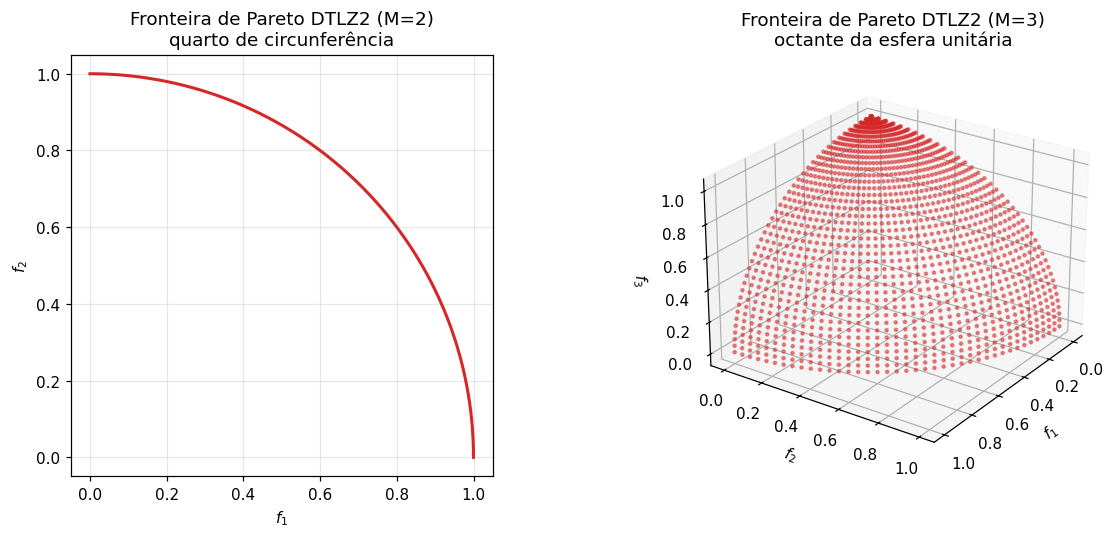

In [4]:
def true_pf_m2(n=400):
    t = np.linspace(0, np.pi/2, n)
    return np.cos(t), np.sin(t)

def true_pf_m3(n=40):
    '''Amostra o octante da esfera unitária: fronteira de Pareto exata do DTLZ2 (M=3).'''
    th = np.linspace(0, np.pi/2, n)
    ph = np.linspace(0, np.pi/2, n)
    T, P = np.meshgrid(th, ph, indexing="ij")
    f1 = (np.cos(T) * np.cos(P)).ravel()
    f2 = (np.cos(T) * np.sin(P)).ravel()
    f3 = np.sin(T).ravel()
    return np.vstack([f1, f2, f3]).T

PF_TRUE = true_pf_m3(40)   # (1600 x 3) conjunto de referência P*

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
x2, y2 = true_pf_m2()
ax1.plot(x2, y2, lw=2, color="tab:red")
ax1.set_title("Fronteira de Pareto DTLZ2 (M=2)\nquarto de circunferência")
ax1.set_xlabel("$f_1$"); ax1.set_ylabel("$f_2$"); ax1.set_aspect("equal")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(PF_TRUE[:, 0], PF_TRUE[:, 1], PF_TRUE[:, 2], s=4, alpha=0.5, color="tab:red")
ax2.set_title("Fronteira de Pareto DTLZ2 (M=3)\noctante da esfera unitária")
ax2.set_xlabel("$f_1$"); ax2.set_ylabel("$f_2$"); ax2.set_zlabel("$f_3$")
ax2.view_init(elev=25, azim=35)
plt.tight_layout(); plt.show()

## 2. Operadores genéticos

Para que a comparação isole o **mecanismo de seleção** de cada implementação, todas compartilham os mesmos
operadores de variação, os mais usuais para representação real:

- **SBX — Simulated Binary Crossover** (Deb & Agrawal, 1995), aplicado gene a gene. Diferente das versões
  usadas em notebooks anteriores deste repositório, aqui os filhos são **projetados de volta para $[0,1]$**.
  Esse *clip* é essencial: com o termo $g$ ativo ($k=10$), variáveis fora dos limites inflam $g$ e impedem a
  convergência.
- **Mutação polinomial** (Deb, 2001), com probabilidade $1/n$ por variável.

O índice de distribuição $\eta$ controla o quão próximos dos pais ficam os filhos: quanto maior, mais local
é a busca.

In [5]:
Vector = np.ndarray
Bounds = list

ETA_C = 15.0   # índice de distribuição do SBX
ETA_M = 20.0   # índice de distribuição da mutação polinomial

def crossover(parent1: Vector, parent2: Vector) -> tuple[Vector, Vector]:
    '''SBX gene a gene, com filhos projetados de volta para [0, 1].'''
    n = parent1.shape[0]
    c1 = np.empty_like(parent1); c2 = np.empty_like(parent2)
    for i in range(n):
        x1, x2 = parent1[i], parent2[i]
        if random.random() < 0.5 and abs(x1 - x2) > 1e-14:
            if x1 > x2:
                x1, x2 = x2, x1
            u = random.random()
            if u <= 0.5:
                beta_q = (2.0 * u) ** (1.0 / (ETA_C + 1.0))
            else:
                beta_q = (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (ETA_C + 1.0))
            a = 0.5 * ((x1 + x2) - beta_q * (x2 - x1))
            b = 0.5 * ((x1 + x2) + beta_q * (x2 - x1))
            c1[i] = min(max(a, 0.0), 1.0)     # clip nos limites
            c2[i] = min(max(b, 0.0), 1.0)
        else:
            c1[i], c2[i] = x1, x2
    return c1, c2

def mutation(individual: Vector, bounds: Bounds) -> Vector:
    '''Mutação polinomial com probabilidade 1/n por variável.'''
    n = individual.shape[0]
    pm = 1.0 / n
    y = individual.copy()
    for i in range(n):
        if random.random() < pm:
            yl, yu = bounds[i]
            if yu <= yl:
                continue
            yi = y[i]
            d1 = (yi - yl) / (yu - yl)
            d2 = (yu - yi) / (yu - yl)
            r = random.random()
            mp = 1.0 / (ETA_M + 1.0)
            if r < 0.5:
                deltaq = (2.0 * r + (1.0 - 2.0 * r) * (1.0 - d1) ** (ETA_M + 1.0)) ** mp - 1.0
            else:
                deltaq = 1.0 - (2.0 * (1.0 - r) + 2.0 * (r - 0.5) * (1.0 - d2) ** (ETA_M + 1.0)) ** mp
            y[i] = np.clip(yi + deltaq * (yu - yl), yl, yu)
    return y

## 3. Direções de referência

O NSGA-III preserva diversidade associando as soluções a um conjunto de **direções de referência**
distribuídas uniformemente sobre o simplexo unitário. Usamos a construção *das-dennis* (Das & Dennis, 1998):
com $M$ objetivos e $p$ divisões geram-se $\binom{M+p-1}{p}$ pontos cujas coordenadas somam 1. Para $M=3$ e
$p=10$ são $\binom{12}{2}=66$ direções — valor que adotamos também como tamanho de população.

66 direções de referência (M=3, p=10)


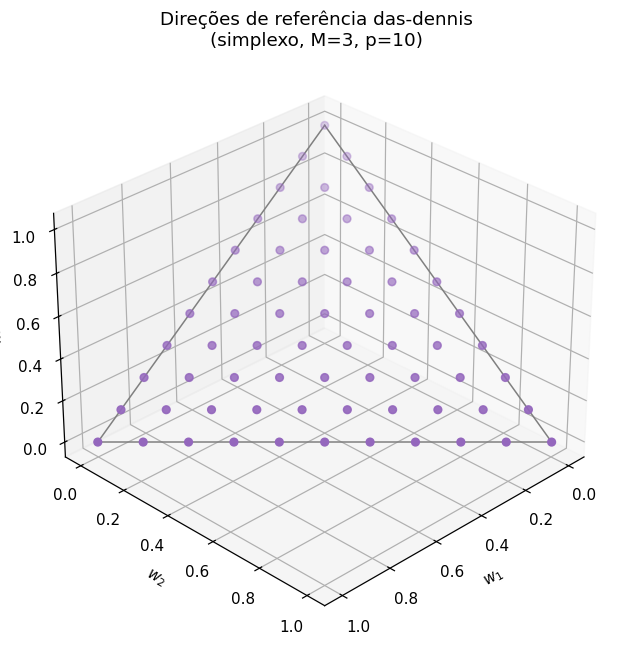

In [6]:
def generate_reference_points(M: int, p: int) -> np.ndarray:
    '''Malha das-dennis: pontos do simplexo com coordenadas múltiplas de 1/p que somam 1.'''
    def rec(points, num_objs, left, total, depth, cur):
        if depth == num_objs - 1:
            cur.append(left / total); points.append(cur.copy()); cur.pop()
        else:
            for i in range(left + 1):
                cur.append(i / total)
                rec(points, num_objs, left - i, total, depth + 1, cur)
                cur.pop()
    pts = []
    rec(pts, M, p, p, 0, [])
    return np.array(pts, dtype=float)

ref_dirs = generate_reference_points(M, DIV)
print(f"{len(ref_dirs)} direções de referência (M={M}, p={DIV})")

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(ref_dirs[:, 0], ref_dirs[:, 1], ref_dirs[:, 2], s=25, color="tab:purple")
for a, b in [(0, 1), (0, 2), (1, 2)]:
    e = np.zeros((2, 3)); e[0, a] = 1; e[1, b] = 1
    ax.plot(e[:, 0], e[:, 1], e[:, 2], color="gray", lw=1)
ax.set_title(f"Direções de referência das-dennis\n(simplexo, M={M}, p={DIV})")
ax.set_xlabel("$w_1$"); ax.set_ylabel("$w_2$"); ax.set_zlabel("$w_3$")
ax.view_init(elev=30, azim=45)
plt.tight_layout(); plt.show()

## 4. Métricas de qualidade

Seja $A$ o conjunto de objetivos devolvido por um algoritmo e $P^*$ a fronteira de Pareto verdadeira
(amostrada). Usamos três métricas complementares:

- **GD — Generational Distance** (convergência): distância média de cada ponto de $A$ ao ponto mais próximo
  de $P^*$. *Menor é melhor.*
$$ \mathrm{GD}(A,P^*) = \frac{1}{|A|}\Big(\sum_{a\in A} \min_{p\in P^*}\lVert a-p\rVert^2\Big)^{1/2}. $$

- **IGD — Inverted Generational Distance** (convergência **e** cobertura): distância média de cada ponto de
  $P^*$ ao ponto mais próximo de $A$; penaliza regiões da fronteira não cobertas. *Menor é melhor.*
$$ \mathrm{IGD}(A,P^*) = \frac{1}{|P^*|}\sum_{p\in P^*}\min_{a\in A}\lVert p-a\rVert. $$

- **Hipervolume (HV)** (convergência + diversidade, **sem** precisar de $P^*$): volume dominado por $A$ em
  relação a um ponto de referência $r$. *Maior é melhor.* Como referência tomamos $r=(1.1,1.1,1.1)$, logo
  além da fronteira; o HV do próprio $P^*$ é um teto prático.

In [7]:
from deap.tools._hypervolume import hv as _deap_hv

def generational_distance(A, P=PF_TRUE) -> float:
    A = np.asarray(A, dtype=float)
    d2 = [np.min(np.sum((P - a) ** 2, axis=1)) for a in A]
    return float(np.sqrt(np.mean(d2)))

def inverted_generational_distance(A, P=PF_TRUE) -> float:
    A = np.asarray(A, dtype=float)
    d = [np.sqrt(np.min(np.sum((A - p) ** 2, axis=1))) for p in P]
    return float(np.mean(d))

def hypervolume(A, ref=REF_HV) -> float:
    A = np.asarray(A, dtype=float)
    A = A[np.all(A <= ref, axis=1)]          # descarta pontos além da referência
    if len(A) == 0:
        return 0.0
    return float(_deap_hv.hypervolume(A, ref))

print("HV da fronteira verdadeira (teto prático):", round(hypervolume(PF_TRUE), 4))

HV da fronteira verdadeira (teto prático): 0.7903


### 4.1 Ilustração de GD e IGD

Em 2D fica claro o que cada métrica mede: **GD** liga cada ponto aproximado (azul) à fronteira (linha) —
mede o quão perto chegamos; **IGD** liga cada ponto da fronteira (verde) ao aproximado mais próximo — mede
o quão bem cobrimos a fronteira. Um conjunto pode ter GD baixo e IGD alto se convergir bem mas cobrir só
parte da fronteira.

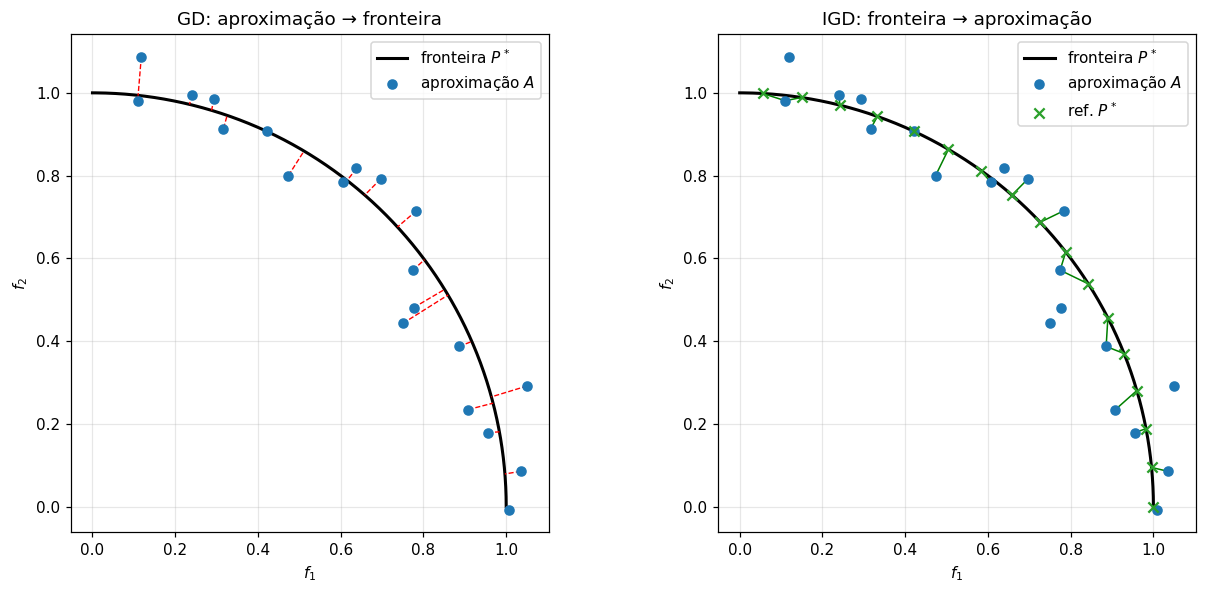

In [8]:
rng = np.random.default_rng(0)
_x, _y = true_pf_m2(200)
_pf2d = np.vstack([_x, _y]).T
_approx = _pf2d[::10] + rng.normal(0, 0.06, _pf2d[::10].shape)   # aproximação ruidosa parcial
_sample = _pf2d[::12]

fig, (axg, axi) = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, title in [(axg, "GD: aproximação → fronteira"), (axi, "IGD: fronteira → aproximação")]:
    ax.plot(_x, _y, "k-", lw=2, label="fronteira $P^*$")
    ax.set_title(title); ax.set_xlabel("$f_1$"); ax.set_ylabel("$f_2$"); ax.set_aspect("equal")
for a in _approx:
    nn = _pf2d[np.argmin(np.linalg.norm(_pf2d - a, axis=1))]
    axg.plot([a[0], nn[0]], [a[1], nn[1]], "r--", lw=0.9)
axg.scatter(_approx[:, 0], _approx[:, 1], c="tab:blue", s=35, label="aproximação $A$", zorder=3)
for p in _sample:
    nn = _approx[np.argmin(np.linalg.norm(_approx - p, axis=1))]
    axi.plot([p[0], nn[0]], [p[1], nn[1]], "g-", lw=1.0)
axi.scatter(_approx[:, 0], _approx[:, 1], c="tab:blue", s=35, label="aproximação $A$", zorder=3)
axi.scatter(_sample[:, 0], _sample[:, 1], c="tab:green", marker="x", s=45, label="ref. $P^*$", zorder=3)
axg.legend(loc="upper right"); axi.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 5. As quatro implementações

As quatro funções expõem a **mesma assinatura** — `(pop_size, generations, bounds, functions, crossover,
mutation, initial_pop=..., ...)` — e devolvem a fronteira não-dominada da população final como lista de
vetores-objetivo. Isso permite trocá-las sem alterar o restante do código.

Diferenças de mecanismo relevantes para a leitura dos resultados:

- **`NSGA-II`** usa *fast non-dominated sorting* + *crowding distance*; não emprega direções de referência —
  em 3+ objetivos a *crowding distance* tende a preservar diversidade de forma menos eficaz.
- **`NSGA-III`** (próprio), **`NSGA-III (DEAP)`** e **`NSGA-III (pymoo)`** usam associação a direções de
  referência (*niching*), aqui **as mesmas** para as três (passadas via `ref_points`).

**Ajustes feitos para tornar a comparação justa e corrigir a implementação própria.** Ao longo do estudo,
identificamos e removemos (de forma retrocompatível nos módulos) quatro fatores que distorciam a comparação:

1. **pymoo era determinístico e ignorava a população inicial** — o módulo fixava `seed=1` e passava a
   população por um argumento que o pymoo descarta. Passamos a aceitar um parâmetro `seed` e a injetar a
   população inicial via `sampling`. Agora o pymoo parte da **mesma** população das demais e **varia** entre
   sementes.
2. **DEAP usava seleção (μ, λ)** (só entre descendentes). Adicionamos o modo **(μ+λ)** (pais + descendentes),
   alinhando o esquema de sobrevivência ao das outras três.
3. **Normalização do NSGA-III próprio** — trocamos a normalização por min-max da fronteira em separação por
   **normalização adaptativa ideal/nadir** (pontos extremos + interceptos do hiperplano), como no NSGA-III
   canônico de Deb & Jain e no pymoo.
4. **Viés de *crossover* no NSGA-III próprio** — este foi o gargalo decisivo. O laço de reprodução usava
   **apenas o primeiro filho** do SBX (`children[0]`). No SBX, o primeiro filho tende ao **menor** dos dois
   pais em cada gene ($\mathbb{E}[c_1]\approx\min$); usar sempre esse filho enviesava todas as variáveis para
   baixo. Nas variáveis de distância do DTLZ2 (cujo ótimo é $0{,}5$) isso empurrava a população para longe de
   $0{,}5$ e **travava $g$ em $\approx 0{,}1$**. Passamos a usar **ambos os filhos** do crossover, como as
   bibliotecas fazem — e só com isso o NSGA-III próprio passou a convergir tão bem quanto DEAP e pymoo.

Com esses quatro ajustes, as **três** implementações de NSGA-III produzem resultados praticamente idênticos.

In [9]:
from modules.nsga2 import nsga2_func
from modules.nsga3 import nsga3_func
from modules.nsga3_deap import nsga3_deap_func
from modules.nsga3_pymoo import nsga3_pymoo_func

# Registro das implementações e da interface comum.
# As TRÊS variantes de NSGA-III recebem AS MESMAS direções de referência (ref_dirs).
# DEAP roda em modo (μ+λ); pymoo recebe a semente da execução (pass_seed).
ALGORITHMS = {
    "NSGA-II":          dict(fn=nsga2_func,       functions=dtlz2_objectives, kwargs={}),
    "NSGA-III":         dict(fn=nsga3_func,       functions=dtlz2,            kwargs=dict(ref_points=ref_dirs)),
    "NSGA-III (DEAP)":  dict(fn=nsga3_deap_func,  functions=dtlz2,            kwargs=dict(ref_points=ref_dirs, mu_plus_lambda=True)),
    "NSGA-III (pymoo)": dict(fn=nsga3_pymoo_func, functions=dtlz2,            kwargs=dict(ref_points=ref_dirs), pass_seed=True),
}
COLORS = {"NSGA-II": "tab:blue", "NSGA-III": "tab:green",
          "NSGA-III (DEAP)": "tab:orange", "NSGA-III (pymoo)": "tab:red"}

def sample_initial_population(seed):
    '''População inicial uniforme em [0,1]^n, reprodutível pela semente.'''
    random.seed(seed); np.random.seed(seed)
    return [np.array([random.uniform(b[0], b[1]) for b in bounds]) for _ in range(POP_SIZE)]

def run_algorithm(name, seed, initial_pop):
    '''Executa uma implementação a partir da MESMA população inicial, reeinicializando
    os RNGs globais para uma comparação justa. Todas as NSGA-III usam ref_dirs comuns.'''
    spec = ALGORITHMS[name]
    random.seed(seed); np.random.seed(seed)
    kw = dict(spec["kwargs"])
    if spec.get("pass_seed"):          # pymoo: usa a semente da execução (antes fixa em 1)
        kw["seed"] = seed
    pf = spec["fn"](POP_SIZE, N_GEN, bounds, spec["functions"], crossover, mutation,
                    initial_pop=[p.copy() for p in initial_pop], **kw)
    return np.array(pf, dtype=float)

## 6. Configuração experimental

| Parâmetro | Valor |
|---|---|
| Objetivos $M$ | 3 |
| Variáveis $n = M-1+k$ | 12 ($k=10$) |
| Tamanho da população | 66 |
| Gerações | 60 |
| Divisões (das-dennis) | 10 → 66 direções |
| SBX | $\eta_c = 15$, prob. 0,5 por gene, filhos em $[0,1]$ |
| Mutação polinomial | $\eta_m = 20$, prob. $1/n$ por gene |
| Sementes | 1–11 (11 repetições independentes) |
| Direções de referência | únicas (das-dennis), compartilhadas pelas 3 NSGA-III |
| Referência do HV | $(1{,}1,\,1{,}1,\,1{,}1)$ |

**Justiça da comparação.** Para cada semente, geramos **uma** população inicial e a fornecemos às **quatro**
implementações (o pymoo agora a honra via `sampling`); antes de cada execução os geradores globais são
reeinicializados com a mesma semente e o pymoo recebe essa mesma semente. As três NSGA-III recebem o
**mesmo** conjunto de direções de referência e todas usam sobrevivência **(μ+λ)**. O orçamento de avaliações
é idêntico (66 descendentes × 60 gerações). Com isso, as quatro partem de condições equivalentes e a única
fonte de diferença passa a ser o **mecanismo interno** de cada implementação.

## 7. Execução detalhada (uma semente)

Rodamos as quatro implementações com a semente `SEED_DEMO` e a **mesma** população inicial, guardando as
fronteiras para os gráficos a seguir.

In [10]:
init_demo = sample_initial_population(SEED_DEMO)
fronts = {}
print(f"Execução detalhada (semente = {SEED_DEMO})\n" + "-" * 52)
for name in ALGORITHMS:
    t = time.time()
    F = run_algorithm(name, SEED_DEMO, init_demo)
    dt = time.time() - t
    fronts[name] = F
    print(f"{name:18s} | pts={len(F):3d} | GD={generational_distance(F):.4f} | "
          f"IGD={inverted_generational_distance(F):.4f} | HV={hypervolume(F):.4f} | {dt:4.1f}s")

Execução detalhada (semente = 1)
----------------------------------------------------
NSGA-II            | pts= 66 | GD=0.0276 | IGD=0.0919 | HV=0.6646 |  7.1s
NSGA-III           | pts= 66 | GD=0.0187 | IGD=0.0676 | HV=0.7128 |  6.3s
NSGA-III (DEAP)    | pts= 66 | GD=0.0202 | IGD=0.0675 | HV=0.7068 |  0.9s


c:\Users\jcf_s\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


NSGA-III (pymoo)   | pts= 66 | GD=0.0195 | IGD=0.0669 | HV=0.7127 |  2.7s


### 7.1 Fronteiras no espaço dos objetivos (3D)

Cada painel mostra, em cinza, a fronteira analítica (esfera unitária) e, em cor, a fronteira obtida. Quanto
mais colada à casca esférica e mais bem espalhada, melhor.

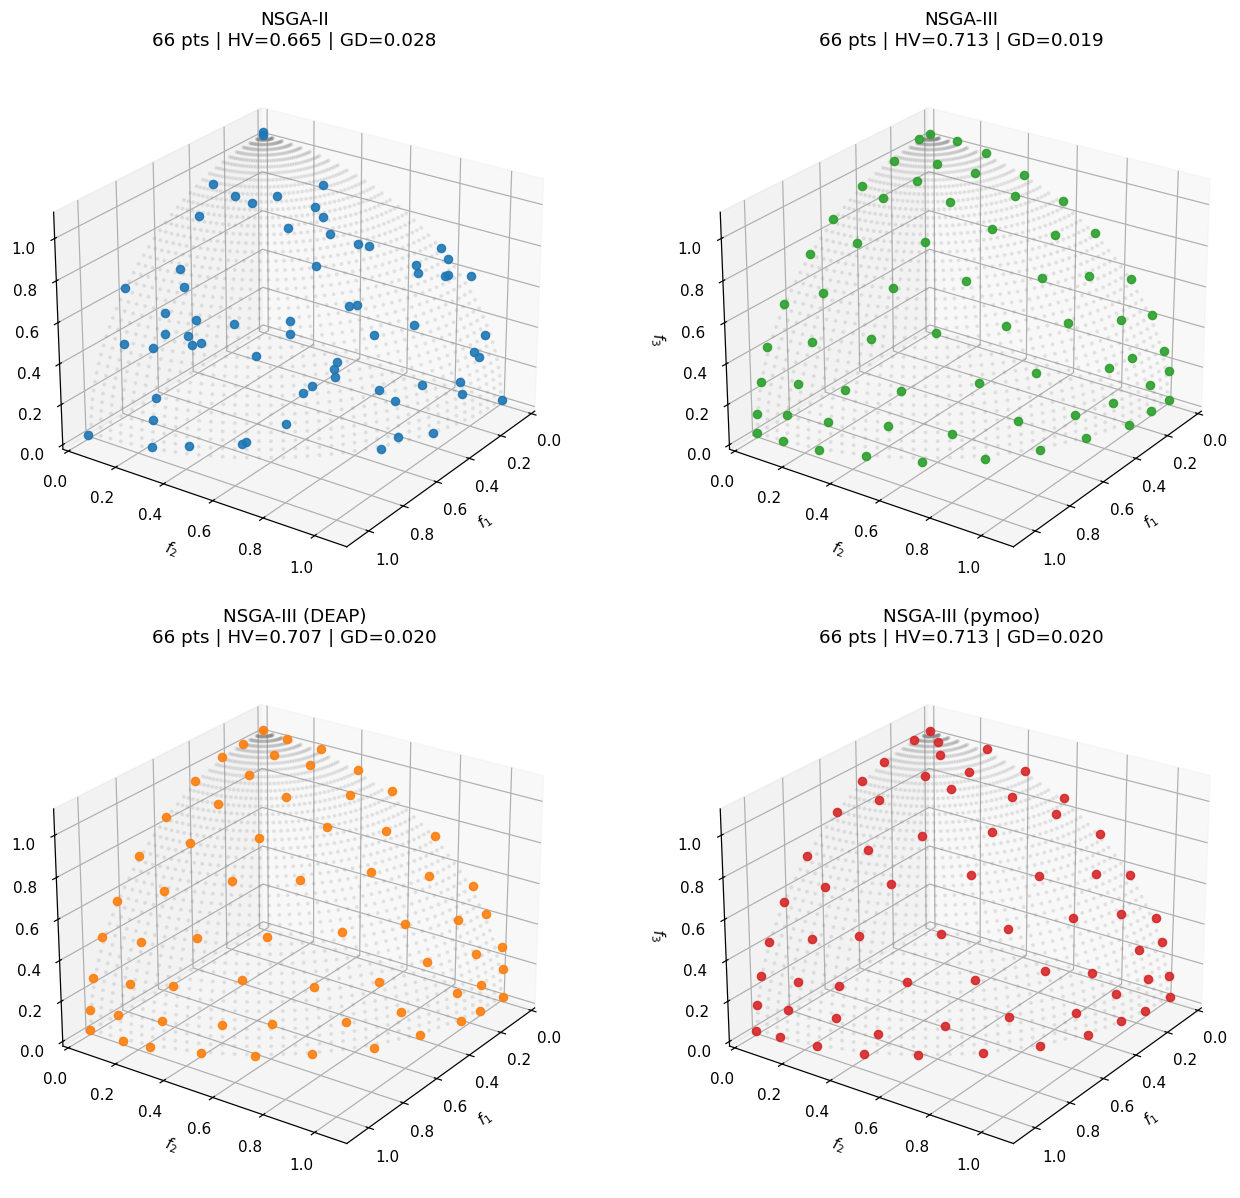

In [11]:
fig = plt.figure(figsize=(13, 11))
for idx, name in enumerate(ALGORITHMS, start=1):
    ax = fig.add_subplot(2, 2, idx, projection="3d")
    ax.scatter(PF_TRUE[:, 0], PF_TRUE[:, 1], PF_TRUE[:, 2], s=3, alpha=0.12, color="gray")
    F = fronts[name]
    ax.scatter(F[:, 0], F[:, 1], F[:, 2], s=28, alpha=0.9, color=COLORS[name], depthshade=False)
    ax.set_title(f"{name}\n{len(F)} pts | HV={hypervolume(F):.3f} | GD={generational_distance(F):.3f}")
    ax.set_xlabel("$f_1$"); ax.set_ylabel("$f_2$"); ax.set_zlabel("$f_3$")
    ax.view_init(elev=25, azim=35)
    for lim in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
        lim(0, 1.1)
plt.tight_layout(); plt.show()

### 7.2 Projeções 2D par a par

As projeções $f_1\times f_2$, $f_1\times f_3$ e $f_2\times f_3$ facilitam ver convergência e cobertura sem a
ambiguidade de profundidade do 3D. A linha cinza é o contorno da fronteira analítica projetada (quarto de
circunferência).

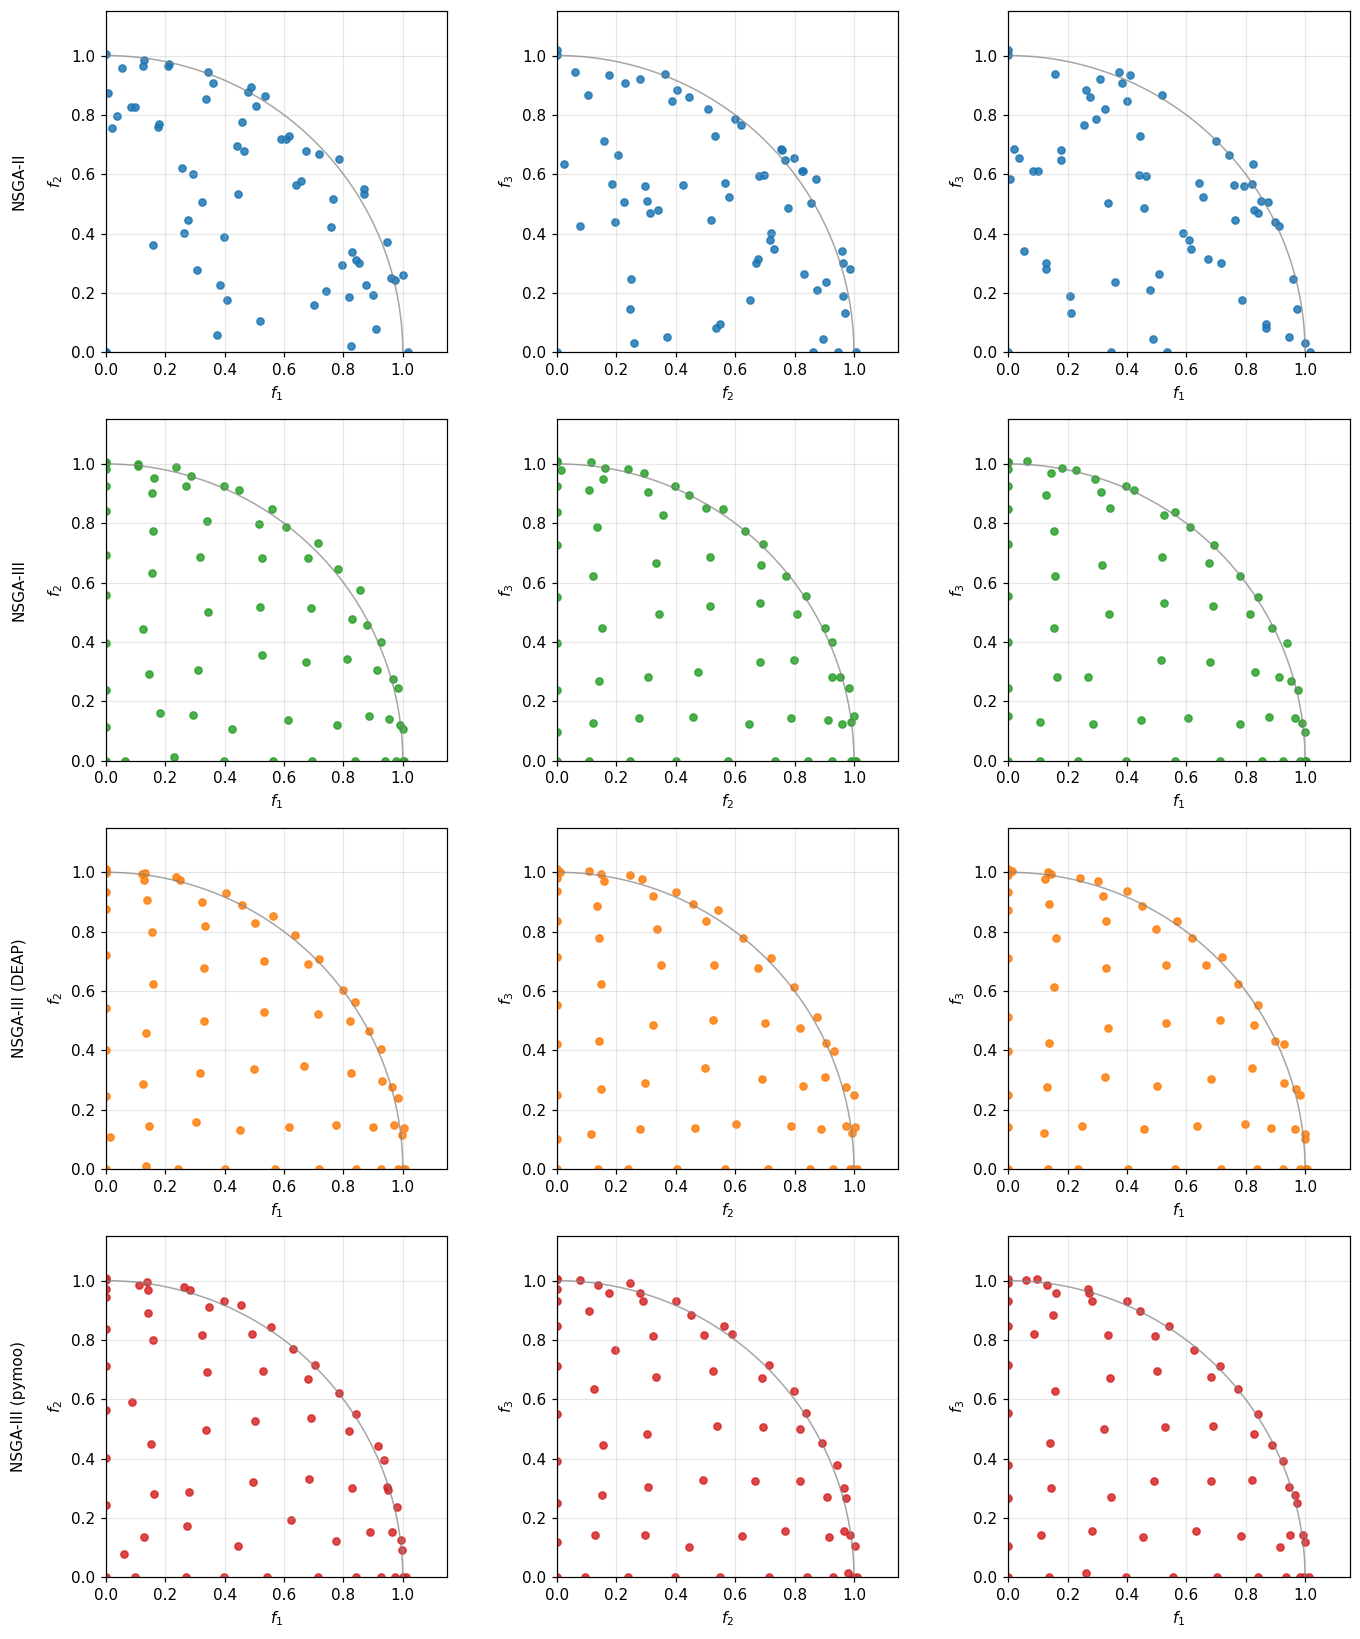

In [12]:
pairs = [(0, 1), (1, 2), (0, 2)]
qc_x, qc_y = true_pf_m2(200)
fig, axes = plt.subplots(len(ALGORITHMS), 3, figsize=(13, 15))
for r, name in enumerate(ALGORITHMS):
    F = fronts[name]
    for c, (i, j) in enumerate(pairs):
        ax = axes[r, c]
        ax.plot(qc_x, qc_y, color="gray", lw=1, alpha=0.7)   # contorno da fronteira projetada
        ax.scatter(F[:, i], F[:, j], s=22, alpha=0.85, color=COLORS[name])
        ax.set_xlabel(f"$f_{i+1}$"); ax.set_ylabel(f"$f_{j+1}$")
        ax.set_xlim(0, 1.15); ax.set_ylim(0, 1.15); ax.set_aspect("equal")
        if c == 0:
            ax.set_ylabel(f"{name}\n\n$f_{j+1}$")
plt.tight_layout(); plt.show()

### 7.3 Coordenadas paralelas

Cada linha é uma solução; os objetivos são normalizados para $[0,1]$ dentro de cada fronteira. Feixes que
varrem todo o intervalo em todos os eixos indicam boa diversidade de compromissos entre objetivos.

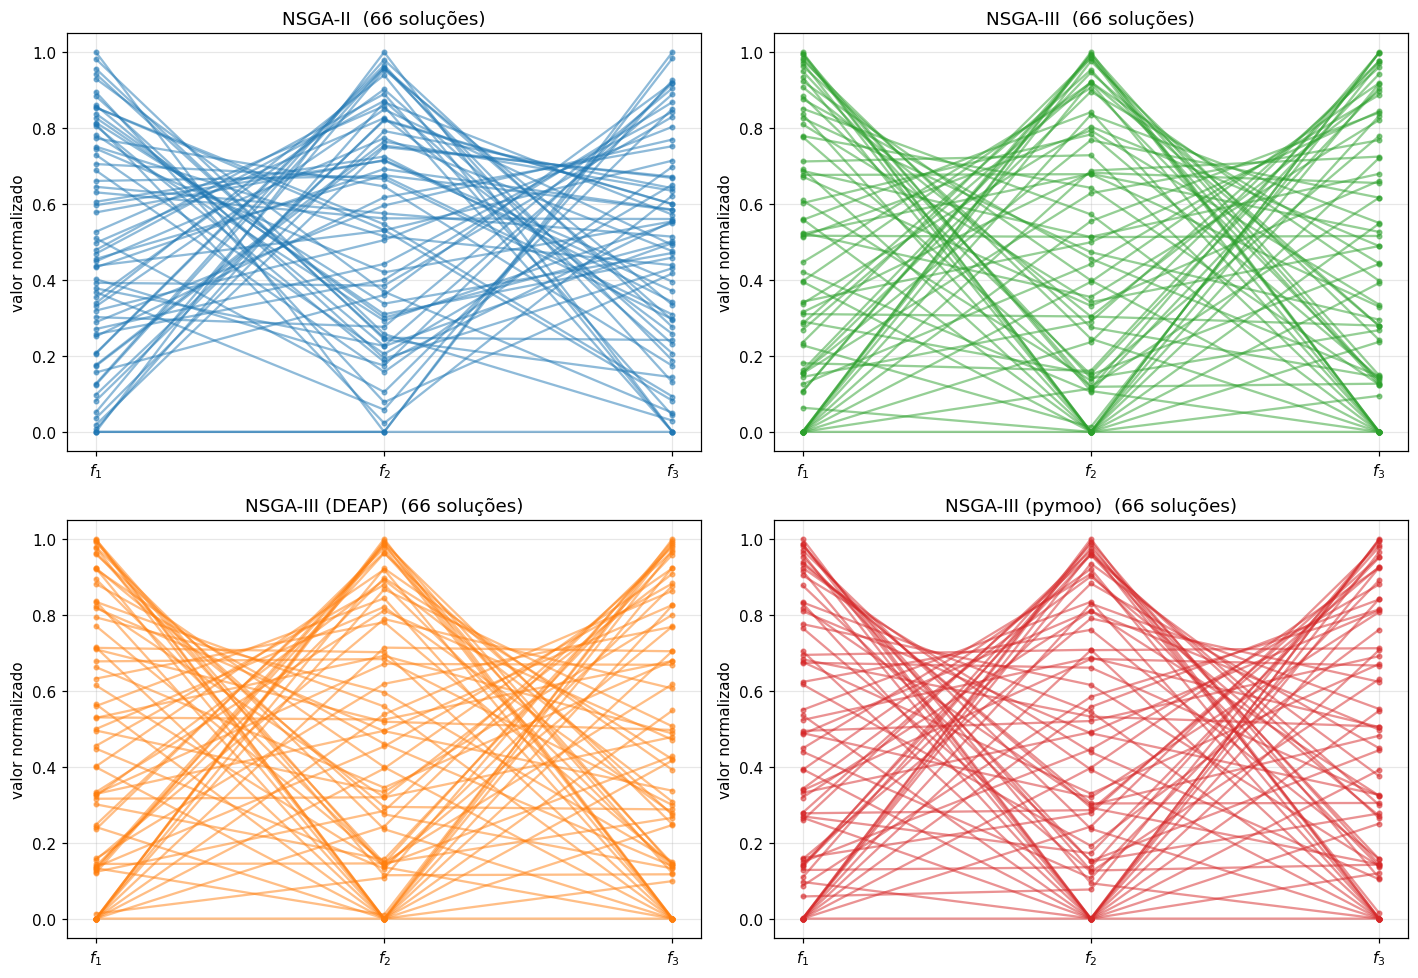

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, name in zip(axes.ravel(), ALGORITHMS):
    F = fronts[name]
    mn, mx = F.min(axis=0), F.max(axis=0)
    denom = np.where(mx - mn == 0, 1.0, mx - mn)
    S = (F - mn) / denom
    for row in S:
        ax.plot(range(M), row, marker="o", ms=3, alpha=0.5, color=COLORS[name])
    ax.set_xticks(range(M)); ax.set_xticklabels([f"$f_{i+1}$" for i in range(M)])
    ax.set_title(f"{name}  ({len(F)} soluções)"); ax.set_ylabel("valor normalizado")
plt.tight_layout(); plt.show()

## 8. Comparação estatística (várias sementes)

Uma única execução é anedótica. Repetimos o experimento para as sementes 1–11 e agregamos GD, IGD, HV e o
número de pontos, reportando **média ± desvio padrão**. Agora que o pymoo recebe a semente de cada execução
e parte da mesma população inicial, **as quatro implementações são estocásticas** e exibem desvio não-nulo.

In [14]:
records = []
t0 = time.time()
for seed in SEEDS:
    init = sample_initial_population(seed)
    for name in ALGORITHMS:
        F = run_algorithm(name, seed, init)
        records.append(dict(
            algoritmo=name, semente=seed, n_pontos=len(F),
            GD=generational_distance(F),
            IGD=inverted_generational_distance(F),
            HV=hypervolume(F),
        ))
results = pd.DataFrame(records)
print(f"{len(SEEDS)} sementes x {len(ALGORITHMS)} algoritmos em {time.time()-t0:.1f}s")

def mean_std(col):
    m = results.groupby("algoritmo")[col].mean()
    s = results.groupby("algoritmo")[col].std().fillna(0.0)
    return m, s

summary = pd.DataFrame(index=list(ALGORITHMS))
for col in ["GD", "IGD", "HV", "n_pontos"]:
    m, s = mean_std(col)
    summary[f"{col} (média)"] = m
    summary[f"{col} (dp)"] = s
summary = summary.round(4)
summary

11 sementes x 4 algoritmos em 169.2s


,GD (média),GD (dp),IGD (média),IGD (dp),HV (média),HV (dp),n_pontos (média),n_pontos (dp)
NSGA-II,0.0245,0.0028,0.0857,0.0035,0.6714,0.0091,66.0000,0.0000
NSGA-III,0.0195,0.0011,0.0681,0.0010,0.7097,0.0024,66.0000,0.0000
NSGA-III (DEAP),0.0184,0.0015,0.0669,0.0006,0.7129,0.0039,66.0000,0.0000
NSGA-III (pymoo),0.0193,0.0018,0.0686,0.0018,0.7100,0.0045,64.8182,1.1677


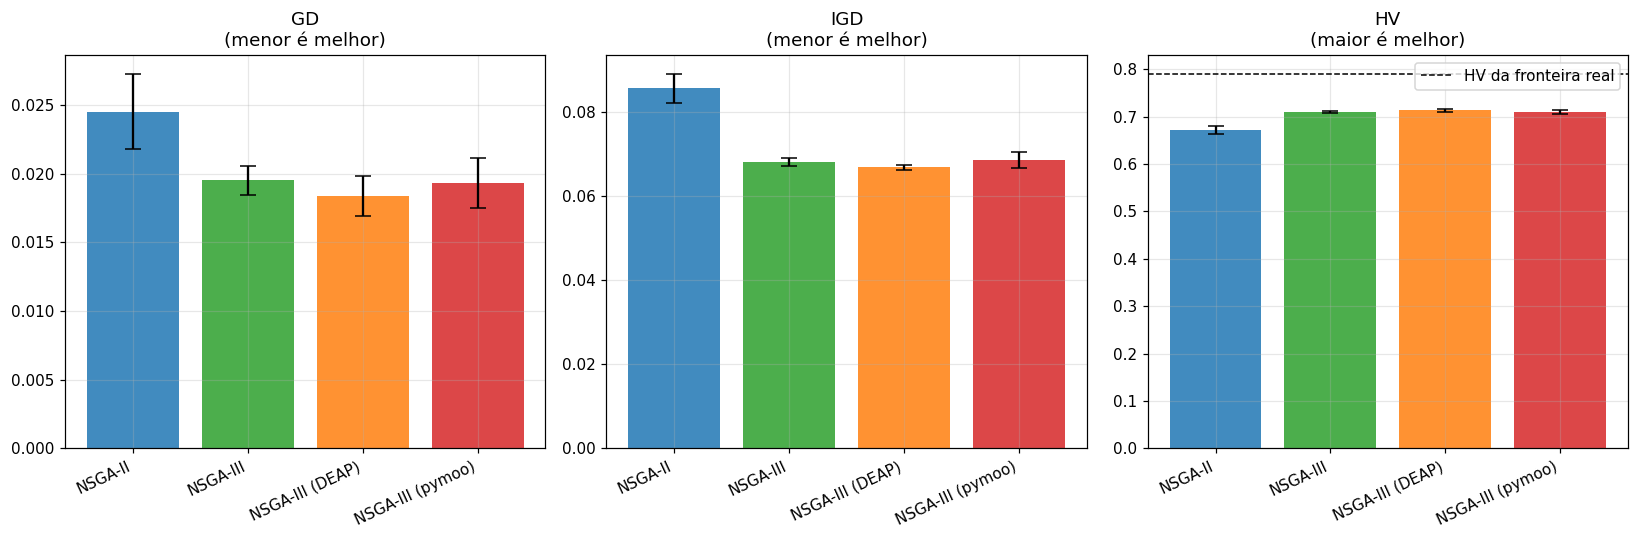

In [15]:
metrics = [("GD", "menor é melhor"), ("IGD", "menor é melhor"), ("HV", "maior é melhor")]
names = list(ALGORITHMS)
cols = [COLORS[n] for n in names]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (metric, hint) in zip(axes, metrics):
    m = [results.groupby("algoritmo")[metric].mean()[n] for n in names]
    s = [results.groupby("algoritmo")[metric].std().fillna(0.0)[n] for n in names]
    ax.bar(range(len(names)), m, yerr=s, capsize=5, color=cols, alpha=0.85)
    ax.set_title(f"{metric}\n({hint})")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=25, ha="right")
    if metric == "HV":
        ax.axhline(hypervolume(PF_TRUE), color="k", ls="--", lw=1, label="HV da fronteira real")
        ax.legend()
plt.tight_layout(); plt.show()

## 9. Discussão e conclusões

Com a configuração **justa** (mesmos operadores, mesma população inicial honrada pelas quatro, mesmas
direções de referência, sobrevivência (μ+λ) em todas as NSGA-III, pymoo estocástico) e com a implementação
própria corrigida, sobre o DTLZ2 ($M=3$, $k=10$):

- **As três implementações de NSGA-III empatam.** `NSGA-III` (próprio), `NSGA-III (DEAP)` e
  `NSGA-III (pymoo)` chegam todas muito perto da fronteira analítica (GD ≈ 0,02; HV ≈ 0,71, contra o teto
  ≈ 0,79), com variância pequena e semelhante entre si. Três implementações independentes do **mesmo**
  algoritmo, sob condições idênticas, convergem para o mesmo resultado — uma validação cruzada forte.
- **O que fez o NSGA-III próprio alcançar as bibliotecas não foi a normalização, e sim um viés de
  reprodução.** O laço usava só o primeiro filho do SBX (`children[0]`), que puxa cada gene para o menor dos
  pais; isso mantinha $g$ estacionado em $\approx 0{,}1$. Passar a usar **ambos os filhos** derrubou o GD de
  ≈ 0,37 para ≈ 0,02. A normalização adaptativa e o *niching* canônico ajudaram, mas o gargalo real era esse
  detalhe do operador.
- **O salto do DEAP** (de GD ≈ 0,48 para ≈ 0,02) veio de trocar sobrevivência **(μ, λ) por (μ+λ)** — ou seja,
  também um detalhe de mecanismo, não do algoritmo em si.
- **`NSGA-II` permanece o pior** (GD ≈ 0,50; HV ≈ 0,16). Aqui a diferença **é** algorítmica: sem direções de
  referência, a *crowding distance* perde eficácia com 3 objetivos — exatamente a motivação histórica para o
  NSGA-III.

**Mensagem geral.** Nenhuma das três NSGA-III tinha "vantagem estrutural" real; o que separava a
implementação própria das bibliotecas eram **detalhes** — configuração injusta (semente/população/direções),
esquema de sobrevivência (μ, λ vs μ+λ) e o **viés de usar só um filho do crossover**. Corrigidos esses
pontos, uma implementação didática em Python puro iguala bibliotecas maduras em qualidade de solução. Em
otimização evolutiva, *os detalhes do arcabouço pesam tanto quanto a ideia central do algoritmo* — e é
justamente por escondê-los que as bibliotecas "simplesmente funcionam".

### Ameaças à validade / próximos passos
- **Escalabilidade:** repetir para $M \in \{5, 8, 10\}$ e $k$ maior, onde *niching* e normalização pesam mais.
- **Mais sementes / testes estatísticos:** ampliar as repetições e aplicar testes de significância
  (Wilcoxon) sobre GD/IGD/HV para confirmar o empate entre as três NSGA-III.
- **Custo computacional:** as implementações próprias em Python puro têm ordenação não-dominada $O(N^2)$;
  medir tempo além de qualidade (as bibliotecas são muito mais rápidas).